             Recency  Frequency  Monetary  R  F  M RFM Score
Customer ID                                                 
1                 57          1      3491  4  1  1       411
2                298          3      7988  2  1  1       211
3                 88          8     22587  3  4  4       344
4                126          4      8715  3  2  1       321
5                170          8     12524  3  4  2       342


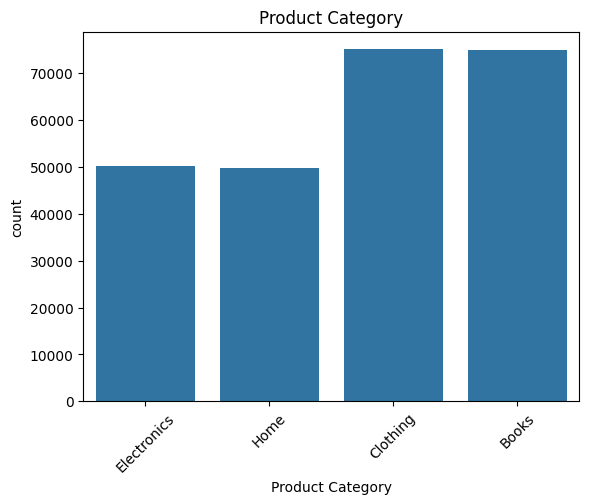

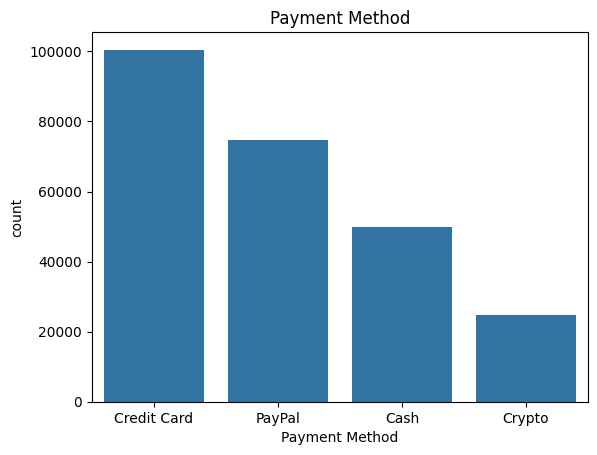

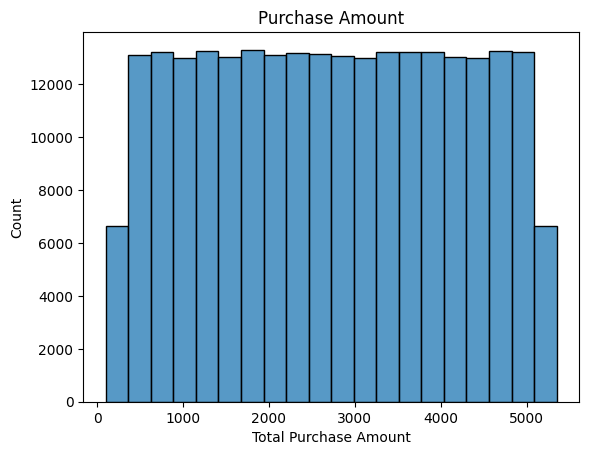

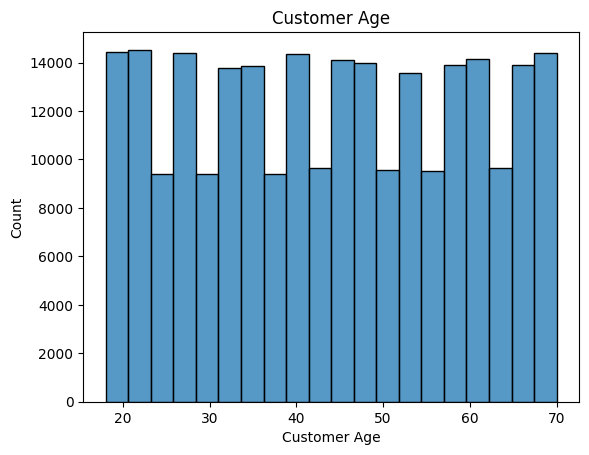

In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')

# 3. Data Cleaning
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# 4. Create RFM Table
today = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (today - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 5. RFM Segmentation
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# 6. Show RFM Table
print(rfm.head())

# 7. Graphs

# Product Category
sns.countplot(data=df, x='Product Category')
plt.title("Product Category")
plt.xticks(rotation=45)
plt.show()

# Payment Method
sns.countplot(data=df, x='Payment Method')
plt.title("Payment Method")
plt.show()

# Purchase Amount
sns.histplot(df['Total Purchase Amount'], bins=20)
plt.title("Purchase Amount")
plt.show()

# Customer Age
sns.histplot(df['Customer Age'], bins=20)
plt.title("Customer Age")
plt.show()